.<center> 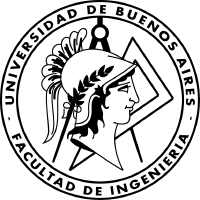



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP9: Naive Bayes**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


## (a) Procesamiento del catálogo

### (a.1)

Se carga el catálogo y el archivo tar con los libros. Las columnas del catálogo son:


*   EPL Id: número Id q
*   Título: título del libro
*   Autor: autor del libro
*   Géneros: géneros del libro
*   Colección: si pertenecen a una colección dice el nombre de esta (NaN si no pertenece a una colección)
*   Volumen: que volumen de la colección es (NaN si no pertenece a una colección)
*   Año publicación: año de publicación del libro
*   Sinopsis: resumen del libro
*   Páginas: N° de páginas del libro
*   Revisión:
*   Idioma: idioma del libro
*   Publicado: fecha que se publicó en la base de datos
*   Estado: si está disponible o no
*   Valoración: valoración promedio del libro
*   N° de votos: cantidad de usuarios que calificaron al libro
*   Enlace(s):



In [2]:
import os
import requests

url_catalog = "https://web.csc.gob.ar/~jzuloaga/epub/catalog.csv"
url_tar = "https://web.csc.gob.ar/~jzuloaga/epub/compressed.tar"

catalog_file = "catalog.csv"
tar_file = "compressed.tar"


if not os.path.exists(catalog_file):
    response = requests.get(url_catalog)
    with open(catalog_file, "wb") as f:
        f.write(response.content)

if not os.path.exists(tar_file):
    response = requests.get(url_tar, stream=True)
    with open(tar_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)


In [3]:
import pandas as pd
import numpy as np

catalog = pd.read_csv("catalog.csv", sep=',', encoding='utf-8')

### (a.2)

Se filtran los libros, quedándose solo con los que están en español.

In [4]:
catalog = catalog[catalog['Idioma'] == 'Español']
print(catalog.shape)

(61063, 16)


### (a.3)

Se filtran los libros del catálogo que no tienen un libro digital correspondiente.

In [5]:
import tarfile
file_names = []
with tarfile.open('compressed.tar', 'r') as tar:
    file_names = tar.getnames()

catalog["filename"] = "compressed/" + catalog["EPL Id"].astype(str) + ".epub"
catalog = catalog[catalog["filename"].isin(file_names)]

## (b) Definición de las clases

### (b.1)

El conjunto de datos presenta una distribución fuertemente desbalanceada entre los géneros literarios. La categoría más representada es “Drama”, con 1082 obras, seguida de “Aventuras” (989), “Policial” (620), “Intriga” (579) y “Realista” (552). Estas cinco categorías concentran una gran proporción del total, lo que indica una fuerte concentración temática hacia los géneros narrativos tradicionales.

Por otro lado, existen numerosas categorías con muy baja representación, por ejemplo, “Tecnología”, “Matemáticas”, “Ucronía” o “Obras completas”, que presentan menos de 5 títulos. Este desbalance puede generar dificultades en las tareas de clasificación automática, ya que los modelos tienden a favorecer las clases más frecuentes.

In [6]:
all_genres = catalog['Géneros'].str.split(',').explode().str.strip()
print(all_genres.value_counts())

Géneros
Drama             1201
Otros             1059
Aventuras         1000
Policial           998
Realista           854
                  ... 
Geografía            2
Cinematografía       2
Física               1
Matemáticas          1
Juegos               1
Name: count, Length: 61, dtype: int64


### (b.2)

Se eliminan los libros que tienen el género "otros", ya que es una categoría redundante.

In [7]:
catalog = catalog[~catalog['Géneros'].str.contains("Otros", case=False, na=False)]
print(catalog.shape)

(7899, 17)


### (b.3)

Cuando un libro posee más de un género asignado, se decidió separar los géneros y asignar a la obra el género menos común dentro de ellos. Esta estrategia busca incrementar la representación de las clases minoritarias y reducir el desbalance global del dataset, permitiendo que el modelo tenga más ejemplos de categorías poco frecuentes.

In [8]:
all_genres = catalog['Géneros'].str.split(',').explode().str.strip()

def least_common_genre(genre_list):
    genres = [g.strip() for g in genre_list.split(',')]
    genres.sort(key=lambda g: all_genres.get(g, float('inf')))
    return genres[0]

In [9]:
catalog["Géneros"] = catalog["Géneros"].apply(least_common_genre)


### (b.4)

Se reporta la distribución final de los géneros.

In [10]:
catalog['Géneros'].value_counts()

,count
Géneros,
Drama,1082
Aventuras,989
Policial,620
Intriga,579
Realista,552
Historia,420
Filosofía,384
Histórico,362
Fantástico,325


### (b.5)

Se separan los conjuntos de entrenamiento y testeo usando la función *train_test_split* con una semilla igual a 103938 que es el padrón del alumno. Se usó una representación de 75% entrenamiento y 25% testeo.

In [11]:
from sklearn.model_selection import train_test_split

seed = 103938
X_train_catalog, X_test_catalog = train_test_split(catalog, test_size=0.25, random_state=seed)


## (c) Preprocesamiento de texto

### (c.1)

In [12]:
pip install ebooklib beautifulsoup4 lxml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.9 MB/s eta 0:00:00


Se extraen los textos de los epubs y se los coloca en una nueva columna del catalog llamada "text".

In [13]:
import tarfile
import io
import zipfile
from bs4 import BeautifulSoup
import pandas as pd

def extract_text_from_epub_in_tar(tar, epub_filename):
    try:
        member = tar.getmember(epub_filename)
        f = tar.extractfile(member)
        epub_bytes = f.read()

        text = ""
        with zipfile.ZipFile(io.BytesIO(epub_bytes)) as z:
            for name in z.namelist():
                if name.endswith(".xhtml") or name.endswith(".html"):
                    with z.open(name) as file:
                        soup = BeautifulSoup(file.read(), "html.parser")
                        text += soup.get_text(separator=" ", strip=True) + " "
        text = text.strip()
        return text if text else None

    except Exception as e:
        print(f"Error al procesar {epub_filename}: {e}")
        return None

tar_path = "compressed.tar"

#X_train_catalog = X_train_catalog.head(1200)
#X_test_catalog = X_test_catalog.head(400)
for df in [X_train_catalog, X_test_catalog]:
    if 'text' not in df.columns:
        df['text'] = None

with tarfile.open(tar_path, 'r') as tar:
    # Procesar conjunto de entrenamiento
    for i in range(len(X_train_catalog)):
        epub_filename = X_train_catalog.iloc[i]['filename']
        text = extract_text_from_epub_in_tar(tar, epub_filename)
        X_train_catalog.iloc[i, X_train_catalog.columns.get_loc('text')] = text

    # Procesar conjunto de testeo
    for i in range(len(X_test_catalog)):
        epub_filename = X_test_catalog.iloc[i]['filename']
        text = extract_text_from_epub_in_tar(tar, epub_filename)
        X_test_catalog.iloc[i, X_test_catalog.columns.get_loc('text')] = text

print("EPUBs procesados de entrenamiento:", len(X_train_catalog))
print("Textos de entrenamieto extraídos correctamente:", X_train_catalog['text'].notna().sum())
print("Vacíos o con error:", X_train_catalog['text'].isna().sum())

print("EPUBs procesados de testeo:", len(X_test_catalog))
print("Textos de testeo extraídos correctamente:", X_test_catalog['text'].notna().sum())
print("Vacíos o con error:", X_test_catalog['text'].isna().sum())

EPUBs procesados de entrenamiento: 5924
Textos de entrenamieto extraídos correctamente: 5904
Vacíos o con error: 20
EPUBs procesados de testeo: 1975
Textos de testeo extraídos correctamente: 1969
Vacíos o con error: 6


### (c.2)

Se aplica el vectorizador de texto *CountVectorizer* para transformar cada libro en una representación numérica basada en la frecuencia de palabras.
Dado que el corpus completo es muy extenso, se implementaron generadores que permiten procesar los textos de manera secuencial y eficiente, evitando cargar toda la base en memoria simultáneamente.

El vectorizador se configuró con los siguientes parámetros:

* max_df = 0.8: se descartan las palabras que aparecen en más del 80 % de los documentos, ya que son muy comunes y no aportan información útil para la clasificación.

* min_df = 5: se eliminan las palabras que aparecen en menos de 5 documentos, ya que su baja frecuencia puede introducir ruido y aumentar la dimensionalidad del modelo sin mejorar el desempeño.

* stop_words = stopwords.words('spanish'): se utiliza la lista de palabras vacías del corpus nltk en español para eliminar términos sin carga semántica relevante, como artículos, preposiciones o pronombres.

De esta forma, el vectorizador aprende un vocabulario equilibrado, compuesto por términos representativos del contenido de los libros, y genera las matrices X_train y X_test que serán utilizadas por el clasificador.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords

# Descargar stopwords
nltk.download('stopwords')
spanish_stopwords = stopwords.words('spanish')

# Crear el vectorizador
vectorizer = CountVectorizer(max_df=0.8, min_df=5, stop_words=spanish_stopwords)

# Filtrar textos vacíos o nulos
X_train_catalog = X_train_catalog[X_train_catalog['text'].notna()]
X_test_catalog = X_test_catalog[X_test_catalog['text'].notna()]
X_train_catalog = X_train_catalog[X_train_catalog['text'].str.strip() != ""]
X_test_catalog = X_test_catalog[X_test_catalog['text'].str.strip() != ""]

y_train = X_train_catalog['Géneros'].values
y_test  = X_test_catalog['Géneros'].values

# Generadores
def text_generator(df):
    for text in df['text']:
        yield text

# Crear y usar generadores
gen_train = text_generator(X_train_catalog)
X_train = vectorizer.fit_transform(gen_train)

gen_test = text_generator(X_test_catalog)
X_test = vectorizer.transform(gen_test)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### (c.3)

En “Estudio en escarlata”, las palabras más frecuentes corresponden a términos relacionados con la investigación policial y el entorno detectivesco, tales como “holmes”, “watson”, “asesinato”, “pistas”, “cuerpo”, “sangre”.
Estas palabras reflejan el tono analítico y de resolución de crímenes característico del género policial.

En cambio, en “Orgullo y prejuicio” predominan términos asociados a las relaciones sociales y el ámbito romántico, como “señor”, “señora”, “bingley”, “elizabet”, “darcy”, “cortesía”, “familia”.
Esto evidencia un enfoque más emocional y de interacción social propio del género romántico.

Al eliminar las palabras comunes a ambos textos (como artículos, verbos generales o descripciones neutras), se logra destacar el vocabulario distintivo de cada género literario.
El resultado confirma que el vectorizador es capaz de capturar patrones léxicos representativos del tipo de obra, validando su funcionamiento para tareas de clasificación.

In [15]:
libro1 = catalog[catalog["Título"].str.contains("Estudio en escarlata", case=False, na=False)].iloc[0]
libro2 = catalog[catalog["Título"].str.contains("Orgullo y prejuicio", case=False, na=False)].iloc[0]

with tarfile.open("compressed.tar", "r") as tar:
    text1 = extract_text_from_epub_in_tar(tar, libro1["filename"])
    text2 = extract_text_from_epub_in_tar(tar, libro2["filename"])

X_books = vectorizer.transform([text1, text2])
words = np.array(vectorizer.get_feature_names_out())

counts_1 = np.array(X_books[0].todense()).ravel()
counts_2 = np.array(X_books[1].todense()).ravel()

df1 = pd.DataFrame({'word': words, 'count': counts_1})
df2 = pd.DataFrame({'word': words, 'count': counts_2})

# Filtramos solo las palabras que aparecen
df1 = df1[df1['count'] > 0]
df2 = df2[df2['count'] > 0]

common_words = set(df1['word']).intersection(set(df2['word']))
df1_unique = df1[~df1['word'].isin(common_words)].sort_values(by='count', ascending=False)
df2_unique = df2[~df2['word'].isin(common_words)].sort_values(by='count', ascending=False)

print("Estudio en escarlata - palabras más frecuentes:")
print(df1_unique.head(40))

print("\nOrgullo y prejuicio - palabras más frecuentes:")
print(df2_unique.head(40))


Estudio en escarlata - palabras más frecuentes:
                 word  count
163577         holmes    159
279884       sherlock     76
142411        ferrier     70
111233        drebber     63
111052          doyle     57
155590        gregson     51
188672       lestrade     47
286752     stangerson     47
164053           hope     43
74253           conan     38
181022      jefferson     36
103698      detective     35
193496           lucy     33
41238              av     30
84911          crimen     23
35781         asesino     20
201338       medicina     20
237248        policía     19
208653       mormones     19
241542  prepublicados     19
181745         joseph     17
287324         strand     17
61924         cazador     17
34780          arthur     17
90958            dedo     16
225992          pared     16
128899      escarlata     16
52556         brixton     15
35775       asesinato     15
41631       aventuras     14
67982            city     14
308884           utah   

## (d) Multinomial Naive Bayes

### (d.1)

El modelo bayes naive multinomial (MNB) propone modelar cada clase $Y=k$ como un proceso de Bernoulli generalizado:

$$X_j|Y=k\sim \text{Cat}(\{\theta_1^{(k)},\cdots,\theta_{V}^{(k)}\})$$

En donde, $V$ es el largo del vocabulario y $1 < k < K$ representa la clase. Cada clase posee probabilidad $c_k$, es decir:

$$Y\sim \text{Cat}(\{c_1,\cdots,c_K\})$$

Para una muestra d-dimensional $\mathbb{x}=(x_1, \cdots, x_d)$ puede calcularse la inferencia como:

$$p(y|\mathbf{x})\propto c_y\cdot \prod_{j=1}^{d} \theta_{x_j}^{(y)} =c_y\cdot\prod_{m=1}^{V}(\theta_m^{(y)})^{N_m}$$


donde $N_m$ representa la cantidad de variables $X_j$ que toman el valor $m$ y son estadísticos suficientes en este modelo. El cambio de variable en la productoria nos permite iterar en los valores $m$ que pueden tomar los predictores. Sea $\mathbf{N} = (N_1, \cdots, N_V)$, no solamente se puede notar que $\sum_{m=1}^VN_m=d$, sino que también nos define la distribución multinomial de estos estadísticos:

$$\mathbf{N}|_{Y=k}\sim\mathcal{M}_n(d,[\theta_1^{(k)},\cdots,\theta_V^{(k)}])$$

El uso de este estadístico nos permite resolver la inferencia como
una solución lineal de la log-probabilidad:

$$\log p(y|x)=cte+\log(c_y)+\sum_{m=1}^VN_m\log(\theta_m^{(y)})$$

La probabilidad de cada clase será estimada por la proporción de muestras que hay en el conjunto de entrenamiento $c_k=\frac{\#\{y_i=k\}}{n}$

dado que las variables $N_m$ cuentan ocurrencias, se pueden compactar todas las muestras de entrenamiento de cada clase en una sola, utilizando suficiencia estadística de las variables categóricas:

$$Ñ_m^{(k)}=\sum_{i=1}^{n}N_{i,m}\cdot \mathbf{1}\{y_i=k\}$$

Esto quiere decir que podemos pensar que tenemos un solo texto por clase, concatenando todos los textos de dicha clase en uno solo. Esto implica que:

$$(Ñ_1^{(k)},\cdots,Ñ_V^{(k)})|_{\mathbf{T}_k=(\theta_1^{(k)},\cdots,\theta_V^{(k)})}\sim\mathcal{M}_n(\tilde{d}^{(k)},[\theta_1^{(k)},\cdots,\theta_V^{(k)}])$$

donde $\tilde{d}^{(k)}$ representa la cantidad de palabras que posee el texto concatenado de la clase k. La variable aleatoria $\mathbf{T}_k$ es una variable representativa de los parámetros del modelo y se modela a priori como:

$$\mathbf{T}_k\sim\text{Dir}([\alpha_1,\cdots,\alpha_V])$$

El vector aleatorio $(\theta_1,\cdots,\theta_V)$ tiene distribución Dirichlett de parámetros $(\alpha_1,\cdots,\alpha_V)$ si su densidad conjunta es de la forma:

$$p(\theta_1,\cdots,\theta_V)=\frac{\prod_{m=1}^{V}\Gamma(\alpha_m)}{\Gamma(\sum_{m=1}^V\alpha_m)}\Bigg(\prod_{m=1}^{V}\theta_m^{\alpha_m-1}\Bigg)\cdot\mathbf{1}\Bigg\{\sum_{m=1}^{V}\theta_m=1, \theta_m\geq0\Bigg\}$$

Las marginales poseen distribución beta $T_m \sim \beta(\alpha_m,\sum_{\eta\neq m}\alpha_{\eta})$ y su esperanza es:

$$\mathbb{E}[T_m]=\frac{\alpha_m}{\sum_{\eta=1}^{V}\alpha_{\eta}}$$

La distribución a posteriori puede calcularse como:

$$p(\theta_1^{(k)},\cdots,\theta_V^{(k)}|Ñ_1^{(k)},\cdots,Ñ_V^{(k)})\\
\\ \propto P\Big(Ñ_1^{(k)},\cdots,Ñ_V^{(k)}|\theta_1^{(k)},\cdots,\theta_V^{(k)}\Big)\cdot p(\theta_1^{(k)},\cdots,\theta_V^{(k)}) \\
\\ \propto \Bigg(\prod_{m=1}^{V}(\theta_m^{(k)})^{Ñ_m^{(k)}}\Bigg)\Bigg(\prod_{m=1}^{V}(\theta_m^{(k)})^{\alpha_m-1}\cdot\mathbf{1}\{\theta_m^{(k)}\geq 0\}\Bigg)\cdot \mathbf{1}\Big\{ \sum_{m=1^{V}}\theta_m^{(k)}=1\Big\}
$$

Con lo cual:

$$\mathbf{T}_k|_{Ñ_1^{(k)},\cdots,Ñ_V^{(k)}}\sim\text{Dir}([Ñ_1^{(k)}+\alpha_1,\cdots,Ñ_V^{(k)}+\alpha_V])$$

De esta manera, utilizando como estimador puntual bayesiano la media a posteriori se obtiene que:

$$\theta_m^{(k)}=\mathbb{E}[T_m|Ñ_1^{(k)},\cdots,Ñ_V^{(k)}]=\frac{N_m^{(k)}+\alpha_m}{\sum_{\eta=1}^VN_{\eta}^{(k)}+\alpha_{\eta}}$$


Una vez estimados los parámetros $c_k$ y $\theta_m^{(k)}$, el modelo puede inferir la clase más probable de un nuevo texto. En la implementación, esto se realiza mediante los métodos predict y predict_proba.

predict_proba() calcula las probabilidades posteriores $P(y=k|X)$ para cada clase y cada texto. Para lograrlo, el modelo evalúa la suma logarítmica de las probabilidades de cada palabra ponderada por su frecuencia en el documento:

$$\log P(Y=k|X)=\log(c_k)+\sum_{m=1}^{V}x_m\log(\theta_m^{(k)})$$

Luego, se aplica una normalización tipo softmax para obtener probabilidades reales que suman 1.

predict() selecciona la clase más probable para cada texto:

$$\hat{y}=\arg \max_{k}\Bigg[\log(c_k)+\sum_{m=1}^{V}x_m\log(\theta_m^{(k)})\Bigg]$$

En términos prácticos, este método devuelve el género literario más probable según las palabras que contiene cada libro.

In [16]:
import numpy as np

class classifierMNB:
    def __init__(self, alpha=1.0):
        self.alpha            = alpha
        self.genres           = None  # lista de géneros
        self.genres_count     = None  # cantidad de libros por género
        self.words_count      = None  # frecuencia de cada palabra para cada genero (n_genres x len(vocabulario))

        self.genres_log_prior = None  # logaritmo de la probabilidad a priori de cada género
        self.words_log_prob   = None  # logaritmo de la probabilidad de cada palabra dado un género

        self.theta            = None

    def fit(self, X, y):

        self.genres = np.unique(y)
        n_genres    = len(self.genres)
        n_words     = X.shape[1]

        self.genres_count = np.zeros(n_genres)
        self.words_count  = np.zeros((n_genres, n_words))

        # cuenta las palabras y libros por género
        for i, c in enumerate(self.genres):
            X_c = X[y == c]
            self.genres_count[i]   = X_c.shape[0]
            self.words_count[i, :] = X_c.sum(axis=0)

        # probabilidad a priori de cada género
        self.genres_log_prior = np.log(self.genres_count / self.genres_count.sum())

        # cálculo de theta
        num        = self.words_count + self.alpha
        den        = num.sum(axis=1).reshape(-1, 1)
        self.theta = num / den

        self.words_log_prob = np.log(self.theta)

    # predicción del género más probeable
    def predict(self, X):
        joint_log_likelihood = X @ self.words_log_prob.T + self.genres_log_prior
        return self.genres[np.argmax(joint_log_likelihood, axis=1)]


    def predict_proba(self, X):
        joint_log_likelihood = X @ self.words_log_prob.T + self.genres_log_prior
        exp_prob = np.exp(joint_log_likelihood)
        return exp_prob / exp_prob.sum(axis=1, keepdims=True)

### (d.2)

El clasificador dummy asigna siempre la clase más probable. Es decir que el accuracy del clasificador dummy es:

$$\text{Accuracy}_{\text{dummy}}=\max_k c_k$$

Por ende, la probabilidad de error asociada a un clasificador dummy será:

$$P_{\text{error}}^{\text{dummy}}=1-\max_k c_k$$

In [19]:
from sklearn.metrics import accuracy_score, f1_score

classifier = classifierMNB()
classifier.fit(X_train, y_train)
y_pred_train = classifier.predict(X_train)
y_pred_test  = classifier.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)

f1_train_macro = f1_score(y_train, y_pred_train, average='macro')
f1_test_macro  = f1_score(y_test, y_pred_test, average='macro')

print(f"Accuracy (train): {acc_train:.4f}")
print(f"Accuracy (test) : {acc_test:.4f}")
print(f"Macro F1 (train): {f1_train_macro:.4f}")
print(f"Macro F1 (test) : {f1_test_macro:.4f}")

# dummy
unique, counts = np.unique(y_train, return_counts=True)
majority_class = unique[np.argmax(counts)]
p_correct = np.max(counts) / np.sum(counts)
p_error = 1 - p_correct


print(f"Clase más frecuente: {majority_class}")
print(f"Accuracy del dummy: {p_correct:.4f}")
print(f"Probabilidad de error del dummy: {p_error:.4f}")

Accuracy (train): 0.8362
Accuracy (test) : 0.5419
Macro F1 (train): 0.7029
Macro F1 (test) : 0.3928
Clase más frecuente: Drama
Accuracy del dummy: 0.1352
Probabilidad de error del dummy: 0.8648


Estos resultados muestran que el modelo aprende patrones relevantes del texto y generaliza de forma razonable. En comparación, un clasificador dummy que siempre predice el género más frecuente (Drama) tendría un accuracy de solo 13.5% y una probabilidad de error del 86.5%.
Esto indica que el modelo Naive Bayes supera ampliamente al dummy, demostrando que realmente está extrayendo información útil del contenido textual y no se limita a predecir las clases más comunes.

### (d.3)

Al analizar las 10 obras más populares (mayor N° de votos) del conjunto de testeo que fueron clasificadas incorrectamente, se observa una tendencia recurrente a predecir el género “Drama”, incluso cuando la obra pertenece a otra categoría como Filosófico, Fantástico o Psicológico.
Esto sugiere que el modelo presenta un sesgo hacia los géneros más frecuentes del corpus, particularmente Drama, que es la clase dominante con más de 1000 obras. Se observa que muchos de los errores de clasificación se producen entre obras cuyos géneros son conceptualmente similares o comparten elementos temáticos.
Estos resultados reflejan que los límites entre géneros literarios son difusos y que la representación textual por palabras no siempre captura el contexto temático o filosófico.
En consecuencia, el modelo tiende a agrupar textos con vocabularios emocionales o narrativos similares dentro del género más común, reforzando el efecto de la desbalanceada distribución de clases en el corpus.

In [18]:
X_test_catalog["y_true"] = y_test
X_test_catalog["y_pred"] = y_pred_test

errores = X_test_catalog[X_test_catalog["y_true"] != X_test_catalog["y_pred"]].copy()

# Ordenar por popularidad
errores = errores.sort_values(by="Nº Votos", ascending=False)

# Tomar los 10 más populares
errores_top10 = errores.head(10)[["Título", "y_true", "y_pred", "Nº Votos"]]

print(errores_top10.to_string(index=False))

                         Título      y_true     y_pred  Nº Votos
   El guardián entre el centeno       Drama   Policial       444
      El retrato de Dorian Gray  Fantástico      Drama       357
                       El túnel       Drama   Realista       286
              El lobo estepario  Filosófico      Drama       271
              Novela de ajedrez Psicológico      Drama       178
              La divina comedia  Fantástico Filosófico       172
                      Ficciones  Fantástico   Memorias       138
         Los hermanos Karamázov       Drama   Realista       130
          La invención de Morel  Fantástico      Drama       128
El asesinato de Rogelio Ackroyd    Policial    Intriga       121
